In [32]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
aisles = pd.read_csv("aisles.csv", encoding= 'utf-8')
departments = pd.read_csv("departments.csv", encoding= 'utf-8')
order_products__prior = pd.read_csv("order_products__prior.csv", encoding= 'utf-8')
order_products__train = pd.read_csv("order_products__train.csv", encoding= 'utf-8')
orders = pd.read_csv("orders.csv", encoding= 'utf-8')
products = pd.read_csv("products.csv", encoding= 'utf-8')

In [35]:
display(aisles.head(2), departments.head(2), order_products__prior.head(2), order_products__train.head(2), orders.head(2), products.head(2))

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses


,department_id,department
0,1,frozen
1,2,other


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13


In [36]:
display(f'aisles : {aisles.shape}, departments : {departments.shape}, order_products__prior : {order_products__prior.shape}, order_products__train : {order_products__train.shape}, orders : {orders.shape}, products : {products.shape}')

'aisles : (134, 2), departments : (21, 2), order_products__prior : (32434489, 4), order_products__train : (1384617, 4), orders : (3421083, 7), products : (49688, 4)'

## 결측치

In [37]:
aisles.isnull().sum()

aisle_id    0
aisle       0
dtype: int64

In [38]:
departments.isnull().sum()

department_id    0
department       0
dtype: int64

In [39]:
order_products__prior.isnull().sum()

order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

In [40]:
order_products__train.isnull().sum()

order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

In [41]:
orders.isnull().sum() # 결측치 있음

order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

In [42]:
products.isnull().sum()

product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64

In [ ]:
orders[(orders['days_since_prior_order'].isnull()) & (orders['eval_set'] == 'prior') & (orders['order_number'] == 1)] # 206209

# days_since_prior_order가 결측치인 경우는 eval_set가 prior인 동시에 order_number가 1

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
11,2168274,2,prior,1,2,11,NaN
26,1374495,3,prior,1,1,14,NaN
39,3343014,4,prior,1,6,11,NaN
45,2717275,5,prior,1,3,12,NaN
...,...,...,...,...,...,...,...
3420930,969311,206205,prior,1,4,12,NaN
3420934,3189322,206206,prior,1,3,18,NaN
3421002,2166133,206207,prior,1,6,19,NaN
3421019,2227043,206208,prior,1,1,15,NaN


## 이상치

In [45]:
orders[['order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']].describe()

,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,3.421083e+06,3.421083e+06,3.421083e+06,3.214874e+06
mean,1.715486e+01,2.776219e+00,1.345202e+01,1.111484e+01
std,1.773316e+01,2.046829e+00,4.226088e+00,9.206737e+00
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00
50%,1.100000e+01,3.000000e+00,1.300000e+01,7.000000e+00
75%,2.300000e+01,5.000000e+00,1.600000e+01,1.500000e+01
max,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01


In [46]:
order_products__prior['add_to_cart_order'].describe()

count    3.243449e+07
mean     8.351076e+00
std      7.126671e+00
min      1.000000e+00
25%      3.000000e+00
50%      6.000000e+00
75%      1.100000e+01
max      1.450000e+02
Name: add_to_cart_order, dtype: float64

In [47]:
order_products__train['add_to_cart_order'].describe()

count    1.384617e+06
mean     8.758044e+00
std      7.423936e+00
min      1.000000e+00
25%      3.000000e+00
50%      7.000000e+00
75%      1.200000e+01
max      8.000000e+01
Name: add_to_cart_order, dtype: float64

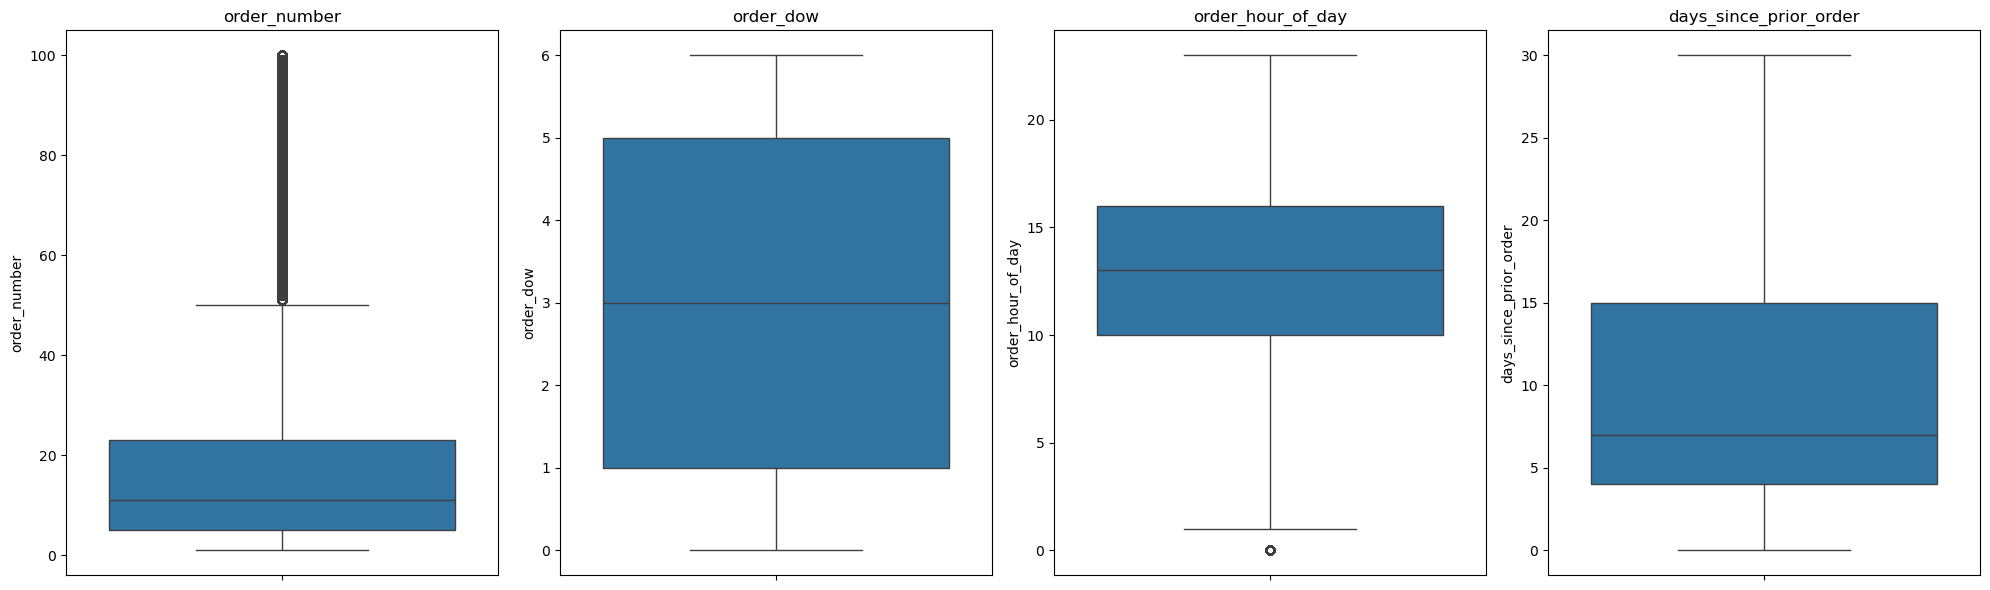

In [ ]:
# 1행 4열의 subplot 생성 (가로 크기를 20으로 넓게 설정)
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

# 첫 번째 그래프: order_number
sns.boxplot(y=orders['order_number'], ax=axes[0])
axes[0].set_title('order_number')

# 두 번째 그래프: order_dow
sns.boxplot(y=orders['order_dow'], ax=axes[1])
axes[1].set_title('order_dow')

# 세 번째 그래프: order_hour_of_day
sns.boxplot(y=orders['order_hour_of_day'], ax=axes[2])
axes[2].set_title('order_hour_of_day')

# 네 번째 그래프: days_since_prior_order
sns.boxplot(y=orders['days_since_prior_order'], ax=axes[3])
axes[3].set_title('days_since_prior_order')

# 그래프 간 간격 자동 조정
plt.tight_layout()
plt.show()

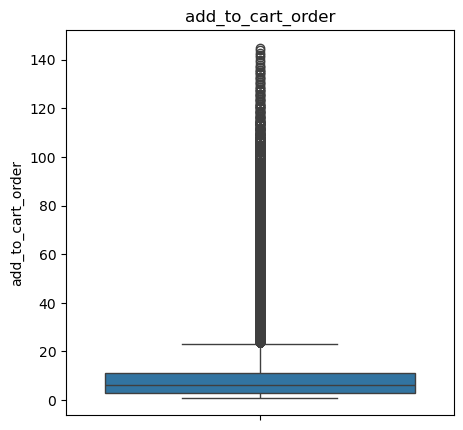

In [57]:
plt.figure(figsize=(5, 5))
sns.boxplot(y=order_products__prior['add_to_cart_order'])
plt.title('add_to_cart_order')
plt.show()

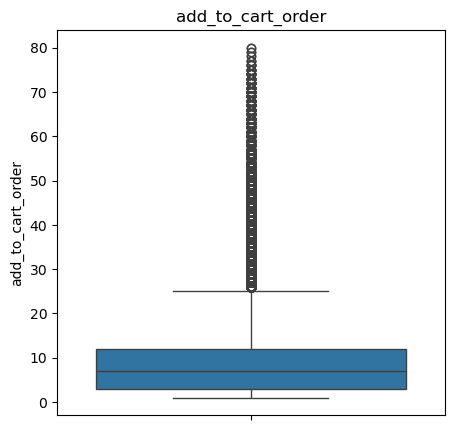

In [58]:
plt.figure(figsize=(5, 5))
sns.boxplot(y=order_products__train['add_to_cart_order'])
plt.title('add_to_cart_order')
plt.show()